# Kaggle House Price 회귀 모델 (DecisionTreeRegressor, Lv3)

- Kaggle House Price 데이터로 **주택 판매 가격(SalePrice)** 을 예측하는 회귀 예제입니다.
- **탐색적 분석(EDA)** 은 생략합니다.
  + 독립변수 전체를 쓰지 않고, 가격과 직관적으로 관련 있는 일부 변수만 선택합니다.
- 데이터 분리 이후, 먼저 **`X_train`에서 함수 없이 직접** 파생변수·바이닝을 진행합니다.
- 이후 같은 과정을 **함수화**하여 `X_test`에도 동일하게 적용합니다.
- 모델은 **Decision Tree Regressor 하나만** 사용하고, 학습 데이터에서 **교차검증**을 진행합니다.

> 오늘의 목표
  + 전처리 함수 만들기의 필요성 인지
  + 모델의 교차검증


## 1. 환경설정

In [37]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [38]:
# ── 1. 기본 및 데이터 처리 라이브러리 ─────────────────────────────────────────
import warnings               # 파이썬 실행 중 발생하는 경고 메시지를 제어하기 위한 모듈
from pathlib import Path      # 파일 및 폴더 경로를 문자열이 아닌 객체로 다루어 경로 연산을 쉽게 해주는 라이브러리

import numpy as np            # 벡터, 행렬 등 다차원 배열 연산과 수치 계산을 빠르고 편리하게 해주는 라이브러리
import pandas as pd           # 표(Table) 형태의 데이터(데이터프레임)를 조작, 정제, 분석하기 위한 핵심 라이브러리
from scipy import stats       # 확률 분포, 가설 검정 등 고급 통계 분석 기능을 제공하는 라이브러리

# ── 2. 시각화 라이브러리 ──────────────────────────────────────────────────
import matplotlib.pyplot as plt          # 파이썬의 가장 기본적인 시각화(그래프 그리기) 라이브러리
import matplotlib.patches as mpatches    # 도형(도형, 화살표 등)을 그래프에 추가할 때 사용하는 모듈
import matplotlib.ticker as mticker      # 그래프의 축 눈금(Tick)을 세밀하게 제어하고 포맷팅하기 위한 모듈
import matplotlib.font_manager as fm     # 시스템에 설치된 폰트를 탐색하고 그래프 폰트로 등록해주는 매니저
import seaborn as sns                    # Matplotlib을 기반으로 더 예쁘고 다양한 통계적 그래프를 쉽게 그릴 수 있는 라이브러리

# ── 3. 머신러닝 라이브러리 (Scikit-learn) ─────────────────────────────────────
# 데이터 분할 및 교차 검증 도구
from sklearn.model_selection import KFold, cross_validate, train_test_split
# KFold: 데이터를 K개의 폴드로 나누어 교차 검증을 수행하는 도구
# cross_validate: 모델의 교차 검증 성능 평가 지표를 계산해주는 함수
# train_test_split: 전체 데이터를 학습용(Train)과 평가용(Test) 데이터로 분할하는 함수

# 결측치 처리 도구
from sklearn.impute import SimpleImputer
# SimpleImputer: 데이터의 빈 부분(결측치)을 평균, 중앙값, 최빈값 등으로 채워주는 도구

# 데이터 스케일링 및 인코딩 도구
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# OneHotEncoder: 범주형(문자열 등) 데이터를 머신러닝이 이해할 수 있도록 0과 1로 변환해주는 도구
# StandardScaler: 수치형 데이터의 평균을 0, 표준편차를 1로 맞추어 스케일(단위)을 통일해주는 도구

# 전처리 파이프라인 도구
from sklearn.compose import ColumnTransformer
# ColumnTransformer: 수치형 컬럼과 범주형 컬럼에 각각 다른 전처리(스케일링, 인코딩 등)를 동시에 적용할 수 있게 묶어주는 도구
from sklearn.pipeline import Pipeline
# Pipeline: 데이터 전처리부터 모델 학습까지의 연속된 과정을 하나의 파이프처럼 묶어 코드를 간결하게 해주는 도구

# 머신러닝 모델
from sklearn.tree import DecisionTreeRegressor
# DecisionTreeRegressor: 스무고개 방식으로 조건을 분기하여 연속적인 수치(가격 등)를 예측하는 의사결정나무 회귀 모델

# 성능 평가 지표
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# mean_absolute_error (MAE): 실제값과 예측값 차이의 절대값 평균 (에러 크기 직관적 확인)
# mean_squared_error (MSE): 실제값과 예측값 차이의 제곱 평균 (큰 에러에 패널티 부여)
# r2_score (R2): 모델이 데이터의 분산을 얼마나 잘 설명하는지 나타내는 결정계수 (1에 가까울수록 성능 좋음)

# 경고 메시지 무시
warnings.filterwarnings('ignore') # 버전에 따른 FutureWarning 등의 불필요한 경고 메시지가 출력되지 않도록 설정

# 랜덤 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)      # 난수 생성 패턴을 42로 고정하여, 코드를 다시 실행해도 매번 동일한 결과가 나오도록 설정

# ── 4. 한국어 폰트 설정 ───────────────────────────────────────────────────
font_dirs = ['/usr/share/fonts/truetype/nanum']         # 나눔 폰트가 설치되어 있는 시스템 폴더 경로 지정
font_files = fm.findSystemFonts(fontpaths=font_dirs)    # 지정한 경로에서 폰트 파일(.ttf) 목록을 모두 찾아 리스트로 반환
for ff in font_files:
    fm.fontManager.addfont(ff)                          # 찾은 개별 폰트 파일들을 Matplotlib 폰트 매니저에 사용할 수 있도록 등록

# ── 5. 시각화 전역 설정 (Wilke 스타일 + 폰트 통합) ──────────────────────────────
# Seaborn 테마 설정 (여기에 폰트를 지정해야 sns 그래프에서도 한글이 깨지지 않음)
sns.set_theme(
    style='whitegrid',                  # 배경을 하얗고 옅은 격자가 있는 스타일로 설정
    rc={
        'font.family': 'NanumBarunGothic', # 그래프의 기본 글꼴을 등록해둔 '나눔바른고딕'으로 설정 (한글 깨짐 방지)
        'axes.unicode_minus': False        # 한글 폰트 적용 시 축의 마이너스(-) 기호가 네모로 깨지는 현상 방지
    }
)

# Matplotlib 세부 스타일 설정 (흰 배경, 최소 격자, 고해상도)
plt.rcParams.update({
    'figure.dpi': 130,                  # 그래프의 해상도를 130 DPI로 설정하여 선명하게 출력
    'figure.facecolor': 'white',        # 그래프 바깥쪽 영역(Figure)의 배경색을 흰색으로 설정
    'axes.facecolor': '#FAFAFA',        # 그래프 안쪽 영역(Axes)의 배경색을 아주 옅은 회색으로 설정
    'axes.spines.top': False,           # 그래프의 위쪽 테두리 선을 숨김 (깔끔한 시각화를 위해)
    'axes.spines.right': False,         # 그래프의 오른쪽 테두리 선을 숨김
    'axes.grid': True,                  # 그래프 내부에 격자선을 표시하도록 설정
    'grid.alpha': 0.3,                  # 격자선의 투명도를 0.3으로 설정 (연하게 표시)
    'grid.linestyle': '--',             # 격자선의 모양을 점선(dash)으로 설정
    'axes.titlesize': 13,               # 그래프 제목(Title)의 글씨 크기를 13으로 설정
    'axes.labelsize': 11,               # x축, y축 이름(Label)의 글씨 크기를 11로 설정
    'xtick.labelsize': 9,               # x축 눈금 숫자들의 글씨 크기를 9로 설정
    'ytick.labelsize': 9,               # y축 눈금 숫자들의 글씨 크기를 9로 설정
    'legend.fontsize': 9,               # 범례(Legend)의 글씨 크기를 9로 설정
})

print('라이브러리 로드 및 시각화 환경 설정 완료')

라이브러리 로드 및 시각화 환경 설정 완료


## 2. 데이터 불러오기

In [39]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import os
from pathlib import Path
import pandas as pd

# PATH를 설정합니다.
DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_house_price')

train_path = DATA_DIR / 'train.csv'
test_path = DATA_DIR / 'test.csv'

# 경로가 올바른지 확인 후 로드합니다.
if train_path.exists() and test_path.exists():
    house = pd.read_csv(train_path)
    kaggle_test = pd.read_csv(test_path)

    print('train.csv shape:', house.shape)
    print('test.csv shape :', kaggle_test.shape)

    # .head() 결과 출력
    display(house.loc[:, ['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt', 'SalePrice']].head())
else:
    print(f"Error: 지정된 경로에 파일이 존재하지 않습니다.\n확인한 경로: {DATA_DIR}")

train.csv shape: (1460, 81)
test.csv shape : (1459, 80)


,Id,OverallQual,GrLivArea,GarageCars,YearBuilt,SalePrice
0,1,7,1710,2,2003,208500
1,2,6,1262,2,1976,181500
2,3,7,1786,2,2001,223500
3,4,7,1717,3,1915,140000
4,5,8,2198,3,2000,250000


## 3. 사용할 변수 일부 선택
- `data_description.txt` 파일 참조
  + 링크 : https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [41]:
# 독립변수 일부 선택
# 처음 회귀 모델을 만들 때는 해석 가능한 일부 변수로 시작하는 것이 좋습니다.

base_features = [
    # 집의 전반적인 품질
    'OverallQual',

    # 면적 관련 변수
    'GrLivArea',
    'TotalBsmtSF',

    # 욕실 관련 변수
    'FullBath',
    'HalfBath',
    'BsmtFullBath',
    'BsmtHalfBath',

    # 차고 관련 변수
    'GarageCars',

    # 연식 계산에 필요한 변수
    'YearBuilt',
    'YrSold',

    # 범주형 변수
    'Neighborhood',
    'HouseStyle',
    'ExterQual',
    'CentralAir',
]

target = 'SalePrice'

X = house.loc[:, base_features].copy()
y = house.loc[:, target].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print()
print('사용할 독립변수:')
print(base_features)


X shape: (1460, 14)
y shape: (1460,)

사용할 독립변수:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'YearBuilt', 'YrSold', 'Neighborhood', 'HouseStyle', 'ExterQual', 'CentralAir']


## 4. 학습 / 테스트 데이터 분리
- 파생변수 생성과 바이닝은 반드시 분리 이후에 진행합니다.
- 결측치 대체와 표준화는 Pipeline 내부에서 처리합니다.
- 그래야 테스트 데이터의 정보가 학습 과정에 섞이지 않습니다.

In [42]:
# 학습·테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f'학습 데이터: {len(X_train)}건')
print(f'테스트 데이터: {len(X_test)}건')
print()
print('X_train 결측치:')
print(X_train.isnull().sum())


학습 데이터: 1168건
테스트 데이터: 292건

X_train 결측치:
OverallQual     0
GrLivArea       0
TotalBsmtSF     0
FullBath        0
HalfBath        0
BsmtFullBath    0
BsmtHalfBath    0
GarageCars      0
YearBuilt       0
YrSold          0
Neighborhood    0
HouseStyle      0
ExterQual       0
CentralAir      0
dtype: int64


## 5. 먼저 `X_train`에서 함수 없이 전처리하기

처음부터 함수를 만들면 학생 입장에서는 “왜 함수가 필요한지”가 잘 보이지 않습니다.

그래서 먼저 `X_train`에서 다음 작업을 직접 해봅니다.

1. 파생변수 추가
2. 바이닝
3. 모델에 사용할 최종 컬럼 선택

결측치 처리와 표준화는 뒤에서 `Pipeline` 내부의 `SimpleImputer`, `StandardScaler`가 담당합니다.


In [43]:
# X_train 복사 및 기본 컬럼 그룹 정의

# 원본 학습 데이터(X_train)가 실수로 변경되는 것을 방지하기 위해 .copy()를 사용해 복사본을 만듭니다.
# 앞으로 수동으로 진행할 전처리 작업은 이 'X_train_manual' 데이터프레임에만 적용합니다.
X_train_manual = X_train.copy()

# 수치형(숫자로 크기나 양을 나타내는) 기본 특징(Feature)들의 컬럼명을 리스트로 묶어 정의합니다.
numeric_base_features = [
    'OverallQual',    # 전반적인 주택 재질 및 마감 품질 (점수)
    'GrLivArea',      # 지상 층의 거실 면적 (평방피트)
    'TotalBsmtSF',    # 지하실 총 면적 (평방피트)
    'FullBath',       # 지상 층의 전체 욕실 개수
    'HalfBath',       # 지상 층의 반쪽 욕실(샤워시설 없는 화장실) 개수
    'BsmtFullBath',   # 지하실의 전체 욕실 개수
    'BsmtHalfBath',   # 지하실의 반쪽 욕실 개수
    'GarageCars',     # 차고에 들어갈 수 있는 차량 대수 (차고 크기)
    'YearBuilt',      # 주택이 건축된 연도
    'YrSold',         # 주택이 판매된 연도
]

# 범주형(문자열이나 카테고리로 종류를 나타내는) 기본 특징들의 컬럼명을 리스트로 묶어 정의합니다.
categorical_base_features = [
    'Neighborhood',   # 주택이 위치한 동네 이름
    'HouseStyle',     # 주택의 스타일 (예: 1층, 2층 등)
    'ExterQual',      # 외관 재질의 품질 (예: Ex(최우수), Gd(우수), TA(평균) 등)
    'CentralAir',     # 중앙 냉방 시설 유무 (Y/N)
]

# 위에서 정의한 수치형/범주형 컬럼 리스트가 잘 만들어졌는지 화면에 출력하여 확인합니다.
print('수치형 기본 컬럼:', numeric_base_features)
print('범주형 기본 컬럼:', categorical_base_features)

수치형 기본 컬럼: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'YearBuilt', 'YrSold']
범주형 기본 컬럼: ['Neighborhood', 'HouseStyle', 'ExterQual', 'CentralAir']


In [44]:
# 결측치 처리는 Pipeline으로 넘기기
# 이렇게 하면 교차검증 과정에서도 각 fold의 학습 데이터 기준으로만
# imputer와 scaler가 fit되어 데이터 누수를 줄일 수 있습니다.
# 실제 선정된 변수로는 결측치는 존재하지 않지만, raw 데이터에는 많은 결측치가 존재합니다.
print('현재 X_train_manual 결측치:')
print(X_train_manual.isnull().sum())


현재 X_train_manual 결측치:
OverallQual     0
GrLivArea       0
TotalBsmtSF     0
FullBath        0
HalfBath        0
BsmtFullBath    0
BsmtHalfBath    0
GarageCars      0
YearBuilt       0
YrSold          0
Neighborhood    0
HouseStyle      0
ExterQual       0
CentralAir      0
dtype: int64


In [45]:
print('실제 raw 데이터 결측치:')
print(house.isnull().sum().values)

실제 raw 데이터 결측치:
[   0    0    0  259    0    0 1369    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0  872    8    0
    0    0   37   37   38   37    0   38    0    0    0    0    0    0
    1    0    0    0    0    0    0    0    0    0    0    0    0    0
    0  690   81   81   81    0    0   81   81    0    0    0    0    0
    0    0 1453 1179 1406    0    0    0    0    0    0]


### 파생변수 만들기
### 💡 코드 요약 (파생변수 생성)

모델이 집값을 더 잘 예측할 수 있도록, 기존 데이터를 조합하여 의미 있는 **파생변수(Derived Features)** 4가지를 새롭게 만드는 과정입니다.

- **`HouseAge` (주택 연식):** 집이 팔린 연도에서 지어진 연도를 빼서 계산합니다. (음수 값은 데이터 오류나 선판매 등을 고려해 0으로 보정)
- **`TotalSF` (총 면적):** 지상 생활 면적과 지하실 면적을 합쳐서 집의 전체 크기를 하나의 숫자로 요약합니다.
- **`TotalBath` (총 욕실 수):** 온전한 욕실(Full)은 1개, 샤워 시설이 없는 욕실(Half)은 0.5개로 취급하여 지상과 지하실의 모든 욕실 수를 합산합니다.
- **`HasGarage` (차고 유무):** 차고에 들어가는 차량 대수 데이터가 1 이상이면 1(있음), 0이면 0(없음)으로 변환합니다. (결측치는 그대로 유지)

In [46]:
# 파생변수(Derived Features) 추가
# 모델의 예측 성능을 높이기 위해 기존 컬럼들을 조합하여 새로운 특징을 만듭니다.
# =====================================================================

# HouseAge   : 매각 연도 기준 집의 나이
# TotalSF    : 지상 생활 면적 + 지하실 전체 면적
# TotalBath  : 전체 욕실 수를 0.5 단위까지 반영
# HasGarage  : 차고 보유 여부

# 1. HouseAge (집의 나이) 계산
# 판매 연도(YrSold)에서 건축 연도(YearBuilt)를 빼서 주택의 실제 연식을 계산합니다.
X_train_manual.loc[:, 'HouseAge'] = (
    X_train_manual.loc[:, 'YrSold'] - X_train_manual.loc[:, 'YearBuilt']
)
# 간혹 리모델링 연도나 데이터 기입 오류로 나이가 음수가 나오는 경우, 0으로 일괄 보정합니다.
X_train_manual.loc[X_train_manual.loc[:, 'HouseAge'] < 0, 'HouseAge'] = 0

# 2. TotalSF (총 생활 면적) 계산
# 지상 거실 면적(GrLivArea)과 지하실 면적(TotalBsmtSF)을 더해 집 전체의 실질적인 크기를 구합니다.
X_train_manual.loc[:, 'TotalSF'] = (
    X_train_manual.loc[:, 'GrLivArea'] + X_train_manual.loc[:, 'TotalBsmtSF']
)

# 3. TotalBath (총 욕실 수) 계산
# Full 욕실은 1, Half 욕실(샤워시설 없는 화장실)은 0.5 가중치를 두어 지상/지하 욕실 개수를 모두 더합니다.
X_train_manual.loc[:, 'TotalBath'] = (
    X_train_manual.loc[:, 'FullBath']
    + 0.5 * X_train_manual.loc[:, 'HalfBath']
    + X_train_manual.loc[:, 'BsmtFullBath']
    + 0.5 * X_train_manual.loc[:, 'BsmtHalfBath']
)

# 4. HasGarage (차고 유무) 생성
# 차고 데이터(GarageCars)가 비어있는(결측치) 행을 먼저 찾습니다.
garage_missing = X_train_manual.loc[:, 'GarageCars'].isnull()

# np.where(조건, 참일 때 값, 거짓일 때 값)을 사용합니다.
# 결측치(비어있는 값)는 그대로 np.nan으로 두고,
# 값이 존재할 경우 차량 대수가 0보다 큰지 판별하여 True(1) / False(0) 형태의 정수(int)로 변환합니다.
X_train_manual.loc[:, 'HasGarage'] = np.where(
    garage_missing,
    np.nan,
    (X_train_manual.loc[:, 'GarageCars'] > 0).astype(int),
)

# 새로 생성된 파생변수 4개가 데이터프레임에 잘 들어갔는지 상위 5개 행을 출력해 확인합니다.
X_train_manual.loc[:, [
    'HouseAge',
    'TotalSF',
    'TotalBath',
    'HasGarage',
]].head()

,HouseAge,TotalSF,TotalBath,HasGarage
254,53,2628,2.0,1.0
1066,16,2370,2.5,1.0
638,98,1592,1.0,0.0
799,70,2499,2.5,1.0
380,86,2717,2.0,1.0


### 바이닝 작업
- 연속형 / 순서형 숫자를 몇 개의 구간으로 묶어 범주형 정보로 바꿉니다.
- 연속적인 숫자 데이터를 특정한 구간(구역)으로 나누어, **범주형(Categorical) 그룹**으로 묶어주는 과정입니다. 모델이 지나치게 세세한 숫자 차이에 민감하게 반응하는 것을 막고, 큰 흐름(패턴)을 파악하도록 돕습니다.
- **`QualBand` (품질 등급):** 1~10점으로 이루어진 전반적인 주택 품질(`OverallQual`)을 점수대에 따라 '보통이하'(0~5), '좋음'(5~7), '매우좋음'(7~10)의 3가지 그룹으로 묶습니다.
- **`AgeBand` (연식 등급):** 계산된 주택 연식(`HouseAge`)을 연차에 따라 **'신축'(20년 이하), '중년'(20~50년), '오래됨'(50년 초과)** 그룹으로 분류합니다.


In [47]:
# 1. QualBand (품질 구간) 생성
# pd.cut() 함수는 지정한 구간(bins)에 맞춰 데이터를 자르고 라벨을 붙여줍니다.
X_train_manual.loc[:, 'QualBand'] = pd.cut(
    X_train_manual.loc[:, 'OverallQual'],  # 기준이 되는 컬럼 (전체 품질 점수)
    bins=[0, 5, 7, 10],                    # 자를 구간의 경계값 (0~5, 5~7, 7~10)
    labels=['보통이하', '좋음', '매우좋음'],   # 각 구간에 부여할 이름
    include_lowest=True,                   # 가장 낮은 경계값(0)을 포함할지 여부
).astype('object')                         # Pandas의 Categorical 타입을 일반 문자열(object)로 변환하여 추후 전처리(인코딩) 시 에러를 방지합니다.

# 2. AgeBand (연식 구간) 생성
X_train_manual.loc[:, 'AgeBand'] = pd.cut(
    X_train_manual.loc[:, 'HouseAge'],     # 기준이 되는 컬럼 (주택 나이)
    bins=[-1, 20, 50, 200],                # 자를 구간 (0~20년, 20~50년, 50~200년) / -1부터 시작해 0살(신축)도 포함되도록 함
    labels=['신축', '중년', '오래됨'],         # 각 구간에 부여할 이름
).astype('object')

# 3. 결과 확인
# 각 구간별로 데이터가 몇 개씩 들어갔는지 빈도수(value_counts)를 출력하여 한쪽으로 과도하게 쏠리지는 않았는지 확인합니다.
print('QualBand 빈도:')
print(X_train_manual.loc[:, 'QualBand'].value_counts())
print()

print('AgeBand 빈도:')
print(X_train_manual.loc[:, 'AgeBand'].value_counts())

QualBand 빈도:
QualBand
좋음      569
보통이하    415
매우좋음    184
Name: count, dtype: int64

AgeBand 빈도:
AgeBand
신축     450
중년     367
오래됨    351
Name: count, dtype: int64


### 모델에 사용할 최종 컬럼 선택

In [48]:
# 모델에 사용할 최종 컬럼 선택
# 파생변수 생성에 직접 사용한 원본 변수는 최대한 제외합니다.

numeric_model_features = [
    'HouseAge',    # YearBuilt, YrSold 기반 파생변수
    'TotalSF',     # GrLivArea, TotalBsmtSF 기반 파생변수
    'TotalBath',   # FullBath, HalfBath, BsmtFullBath, BsmtHalfBath 기반 파생변수
    'HasGarage',   # GarageCars 기반 파생변수
]

categorical_model_features = [
    'Neighborhood',
    'HouseStyle',
    'ExterQual',
    'CentralAir',
    'QualBand',    # OverallQual 기반 바이닝 변수
    'AgeBand',     # HouseAge 기반 바이닝 변수
]

model_features = numeric_model_features + categorical_model_features

X_train_ready_manual = X_train_manual.loc[:, model_features].copy()

print('모델 입력 데이터 shape:', X_train_ready_manual.shape)
X_train_ready_manual.head()

모델 입력 데이터 shape: (1168, 10)


,HouseAge,TotalSF,TotalBath,HasGarage,Neighborhood,HouseStyle,ExterQual,CentralAir,QualBand,AgeBand
254,53,2628,2.0,1.0,NAmes,1Story,TA,Y,보통이하,오래됨
1066,16,2370,2.5,1.0,Gilbert,2Story,Gd,Y,좋음,신축
638,98,1592,1.0,0.0,Edwards,1Story,TA,Y,보통이하,오래됨
799,70,2499,2.5,1.0,SWISU,1.5Fin,TA,Y,보통이하,오래됨
380,86,2717,2.0,1.0,SWISU,1.5Fin,TA,Y,보통이하,오래됨


## 6. 반복되는 전처리를 함수화하기

방금 `X_train`에서 한 작업을 그대로 `X_test`에도 해야 합니다.

여기서 함수가 필요해집니다.

- 같은 규칙을 재사용할 수 있습니다.
- 실수로 train/test에 다른 전처리를 적용하는 일을 줄입니다.
- 나중에 새로운 데이터 1건을 예측할 때도 같은 함수를 사용할 수 있습니다.


In [49]:
# 전처리 함수 만들기
# 파생변수 생성 및 바이닝(Binning) 코드를 모아 하나의 함수로 정의합니다.

def prepare_house_features(data):
    """House Price 데이터의 파생변수와 바이닝을 적용합니다.

    이 함수는 결측치를 대체하지 않습니다.
    결측치 대체와 표준화는 모델 Pipeline 내부에서 처리합니다.

    Parameters
    ----------
    data : pd.DataFrame
        전처리할 원본 독립변수 데이터입니다.

    Returns
    -------
    pd.DataFrame
        모델 입력용 최종 특성 데이터입니다.
    """

    # 1. 데이터 복사
    # 원본 데이터가 변경되는 것을 막기 위해 복사본(prepared)을 생성하여 작업합니다.
    prepared = data.copy()

    # 2. HouseAge (주택 연식) 계산 및 보정
    prepared.loc[:, 'HouseAge'] = (
        prepared.loc[:, 'YrSold'] - prepared.loc[:, 'YearBuilt']
    )
    # 연식이 0보다 작은 이상치 데이터는 0으로 일괄 처리합니다.
    prepared.loc[prepared.loc[:, 'HouseAge'] < 0, 'HouseAge'] = 0

    # 3. TotalSF (총 생활 면적) 계산
    # 지상 거실 면적 + 지하실 총 면적
    prepared.loc[:, 'TotalSF'] = (
        prepared.loc[:, 'GrLivArea'] + prepared.loc[:, 'TotalBsmtSF']
    )

    # 4. TotalBath (총 욕실 수) 계산
    # 샤워 시설이 없는 화장실(HalfBath)은 0.5개로 취급하여 모두 합산합니다.
    prepared.loc[:, 'TotalBath'] = (
        prepared.loc[:, 'FullBath']
        + 0.5 * prepared.loc[:, 'HalfBath']
        + prepared.loc[:, 'BsmtFullBath']
        + 0.5 * prepared.loc[:, 'BsmtHalfBath']
    )

    # 5. HasGarage (차고 유무) 생성
    # 차고 데이터가 비어있으면(결측치) 그대로 두고, 값이 있으면 0보다 큰지(차고가 있는지) 여부를 1과 0으로 나타냅니다.
    garage_missing = prepared.loc[:, 'GarageCars'].isnull()
    prepared.loc[:, 'HasGarage'] = np.where(
        garage_missing,
        np.nan,
        (prepared.loc[:, 'GarageCars'] > 0).astype(int),
    )

    # 6. QualBand (품질 등급 바이닝)
    # 전체 품질 점수(0~10)를 '보통이하', '좋음', '매우좋음' 3가지 범주로 묶어줍니다.
    prepared.loc[:, 'QualBand'] = pd.cut(
        prepared.loc[:, 'OverallQual'],
        bins=[0, 5, 7, 10],
        labels=['보통이하', '좋음', '매우좋음'],
        include_lowest=True,
    ).astype('object')

    # 7. AgeBand (연식 등급 바이닝)
    # 집의 연식(0~200년)을 '신축', '중년', '오래됨' 범주로 묶어줍니다.
    prepared.loc[:, 'AgeBand'] = pd.cut(
        prepared.loc[:, 'HouseAge'],
        bins=[-1, 20, 50, 200],
        labels=['신축', '중년', '오래됨'],
    ).astype('object')

    # 8. 최종 데이터 반환
    # 전역 변수로 정의되어 있을 'model_features' 리스트를 참조하여,
    # 모델 학습에 사용할 핵심 컬럼들만 뽑아낸 뒤 복사본으로 반환합니다.
    return prepared.loc[:, model_features].copy()

In [50]:
# 함수로 X_train / X_test 전처리

X_train_ready = prepare_house_features(X_train)
X_test_ready = prepare_house_features(X_test)

print('수동 처리 결과와 함수 처리 결과가 같은가?')
print(X_train_ready.equals(X_train_ready_manual))
print()
print('X_train_ready shape:', X_train_ready.shape)
print('X_test_ready shape :', X_test_ready.shape)
print()
print('결측치는 아직 남아 있을 수 있으며, Pipeline 내부에서 처리합니다.')
X_train_ready.head()


수동 처리 결과와 함수 처리 결과가 같은가?
True

X_train_ready shape: (1168, 10)
X_test_ready shape : (292, 10)

결측치는 아직 남아 있을 수 있으며, Pipeline 내부에서 처리합니다.


,HouseAge,TotalSF,TotalBath,HasGarage,Neighborhood,HouseStyle,ExterQual,CentralAir,QualBand,AgeBand
254,53,2628,2.0,1.0,NAmes,1Story,TA,Y,보통이하,오래됨
1066,16,2370,2.5,1.0,Gilbert,2Story,Gd,Y,좋음,신축
638,98,1592,1.0,0.0,Edwards,1Story,TA,Y,보통이하,오래됨
799,70,2499,2.5,1.0,SWISU,1.5Fin,TA,Y,보통이하,오래됨
380,86,2717,2.0,1.0,SWISU,1.5Fin,TA,Y,보통이하,오래됨


## Decision Tree 회귀 모델 만들기

- 데이터 전처리 과정(결측치 채우기, 스케일링, 인코딩)과 모델 학습 과정을 하나의 캡슐처럼 묶어주는 파이프라인(Pipeline)을 만드는 과정입니다.

- **데이터 누수(Data Leakage) 방지:** 전처리를 미리 다 해놓고 교차 검증을 하면 평가용 데이터의 정보가 학습 과정에 스며드는 문제가 발생합니다. 파이프라인을 사용하면 매 폴드(Fold)마다 오직 학습용 데이터의 통계값(중앙값, 최빈값 등)만 사용하여 전처리를 수행하므로 이를 완벽히 방지할 수 있습니다.
- **수치형 파이프라인 (`numeric_transformer`):** 숫자로 된 데이터는 빈칸을 중앙값(Median)으로 채우고, 크기 단위가 다른 변수들의 스케일을 동일하게 맞춰줍니다(**StandardScaler**).
- **범주형 파이프라인 (`categorical_transformer`):** 문자나 카테고리로 된 데이터는 빈칸을 최빈값(가장 자주 나오는 값)으로 채우고, 모델이 계산할 수 있도록 0과 1의 형태로 변환합니다(**OneHotEncoder**).
- **컬럼 변환기 (`ColumnTransformer`):** 수치형 컬럼과 범주형 컬럼이 각각 자신에게 맞는 파이프라인을 통과하도록 교통정리를 해줍니다.
- **최종 통합 (`pipeline`):** 데이터 전처리기(`preprocessor`)와 의사결정나무 모델(`tree_model`)을 하나로 연결하여, 원본 데이터만 넣으면 알아서 전처리와 예측까지 수행하는 자동화 통로를 완성합니다.


In [63]:
# 1. 수치형 데이터 전처리 파이프라인
numeric_transformer = Pipeline([
    # 결측치(빈칸)를 해당 컬럼의 중앙값(median)으로 채웁니다.
    ('imputer', SimpleImputer(strategy='median')),
    # 데이터의 평균을 0, 표준편차를 1로 맞춰 값의 단위를 통일(스케일링)합니다.
    ('scaler', StandardScaler()),
])

# 2. 범주형 데이터 전처리 파이프라인
categorical_transformer = Pipeline([
    # 결측치를 해당 컬럼에서 가장 자주 등장하는 최빈값(most_frequent)으로 채웁니다.
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # 범주형 데이터를 0과 1로 이루어진 가변수(Dummy variable)로 변환합니다.
    # handle_unknown='ignore': 학습할 때 못 봤던 새로운 카테고리가 테스트 데이터에 나오면 에러를 내지 않고 모두 0으로 처리합니다.
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# 3. 컬럼 변환기 (ColumnTransformer)
# 위에서 만든 파이프라인들을 어떤 컬럼들에 각각 적용할지 매핑해줍니다.
preprocessor = ColumnTransformer([
    # 'num'이라는 이름으로, 수치형 파이프라인을 'numeric_model_features' 리스트에 담긴 컬럼들에 적용
    ('num', numeric_transformer, numeric_model_features),
    # 'cat'이라는 이름으로, 범주형 파이프라인을 'categorical_model_features' 리스트에 담긴 컬럼들에 적용
    ('cat', categorical_transformer, categorical_model_features),
])

# 4. 머신러닝 모델 정의 (의사결정나무 회귀 모델)
tree_model = DecisionTreeRegressor(
    max_depth=5,            # 나무의 최대 깊이를 5로 제한 (과적합 방지)
    min_samples_leaf=10,    # 마지막 잎 노드(Leaf)에 최소 10개의 데이터가 있어야 분할을 승인 (과적합 방지)
    random_state=RANDOM_STATE, # 매번 동일한 결과를 얻기 위해 난수 시드 고정
)

# 5. 최종 파이프라인 결합
# 데이터가 들어오면 전처리기(preprocessor)를 먼저 거치고, 변환된 데이터가 모델(tree_model)로 들어가도록 하나로 묶습니다.
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', tree_model),
])

# 주피터 노트북(Colab) 환경에서 파이프라인 객체를 맨 마지막 줄에 작성하면,
# 시각적으로 어떻게 구성되어 있는지 다이어그램(HTML) 형태로 출력해 줍니다.
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['HouseAge', 'TotalSF',
                                                   'TotalBath', 'HasGarage']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Neighborhood', 'HouseStyle',
                                                   'ExterQual', 'CentralAir',
                                                   'QualBand', 'AgeBand'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=10,
                                       random_state=42))])

## 8. 교차검증 진행

- 모델이 처음 보는 데이터에도 잘 작동하는지(일반화 성능) 확인하기 위해, 데이터를 여러 조각으로 나누어 번갈아 가며 시험을 치르는 **K-Fold 교차 검증** 과정입니다.
- **K-Fold 교차 검증:** 전체 학습 데이터를 5개(Fold)의 조각으로 나눈 뒤, 4개는 학습용으로 1개는 평가(모의고사)용으로 사용하는 과정을 5번 반복하여 평균적인 성능을 검증합니다.
- **평가 지표 세팅:** 모델의 성능을 판단할 채점 기준으로 RMSE(평균 오차 크기에 패널티 부여), MAE(직관적인 평균 오차 크기), R2(모델의 설명력) 세 가지를 동시에 사용합니다.
- **음수 점수 보정:** 사이킷런(Scikit-learn)은 내부 구조상 '값이 클수록 성능이 좋다'고 판단하도록 설계되어 있습니다. 그래서 오차(Error) 지표들 앞에 마이너스(`neg_`)를 붙여 음수로 계산하게 되는데, 최종 결과를 사람이 보기 편하게 다시 양수로 되돌려줍니다.
- **과적합(Overfitting) 확인:** 학습용 데이터의 성적(`train_score`)과 모의고사 성적(`valid_score`)을 나란히 표로 만들어, 모델이 학습 데이터의 정답만 외우고 있는 것은 아닌지 비교합니다.

In [52]:
# 1. K-Fold 객체 생성
# 전체 데이터를 5개(n_splits=5)의 조각(Fold)으로 쪼개는 규칙을 만듭니다.
# 데이터를 쪼개기 전에 골고루 섞어주어(shuffle=True) 특정 패턴이 몰리지 않게 합니다.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 2. 평가 지표(Scoring) 딕셔너리 정의
# 사이킷런의 채점 시스템은 점수가 높을수록 좋은 것으로 인식합니다.
# 따라서 오차값(Error)인 RMSE와 MAE는 내부적으로 음수(neg_)로 계산되도록 이름이 정해져 있습니다.
scoring = {
    'rmse': 'neg_root_mean_squared_error', # 평균 제곱근 오차 (실제값과 예측값 차이)
    'mae': 'neg_mean_absolute_error',      # 평균 절대 오차
    'r2': 'r2',                            # 결정계수 (1에 가까울수록 성능 좋음, 이건 원래 클수록 좋으므로 neg_가 안 붙음)
}

# 3. 교차 검증 실행
cv_results = cross_validate(
    pipeline,          # 앞에서 만든 전처리+모델 결합 파이프라인
    X_train_ready,     # 파생변수와 바이닝 처리가 완료된 학습용 독립변수 데이터
    y_train,           # 예측해야 할 정답 (집값 데이터)
    cv=cv,             # 위에서 정의한 5-Fold 분할 규칙
    scoring=scoring,   # 채점할 기준 3가지
    return_train_score=True, # 평가용 폴드의 점수뿐만 아니라, 학습에 썼던 폴드의 점수도 같이 반환할지 여부
)

# 4. 결과 정리 (데이터프레임 변환)
# 5번의 반복 실험 결과를 보기 쉽게 표(DataFrame) 형태로 정리합니다.
cv_summary = pd.DataFrame({
    'fold': np.arange(1, 6),              # 1회차부터 5회차까지 폴드 번호
    # 사이킷런이 강제로 음수로 만든 오차(RMSE, MAE) 값에 마이너스(-)를 다시 붙여 직관적인 양수로 되돌립니다.
    'train_rmse': -cv_results['train_rmse'],
    'valid_rmse': -cv_results['test_rmse'],
    'train_mae': -cv_results['train_mae'],
    'valid_mae': -cv_results['test_mae'],
    # R2 점수는 원래부터 클수록 좋은 값이므로 그대로 사용합니다.
    'train_r2': cv_results['train_r2'],
    'valid_r2': cv_results['test_r2'],
})

# 5. 결과 출력
# 소수점 아래 2자리까지만 반올림(.round(2))하여 깔끔하게 출력합니다.
cv_summary.round(2)

,fold,train_rmse,valid_rmse,train_mae,valid_mae,train_r2,valid_r2
0,1,32530.24,37302.03,21408.90,26332.81,0.82,0.78
1,2,31792.44,40298.14,21275.95,25396.09,0.83,0.72
2,3,31036.45,44903.29,21710.60,26895.41,0.83,0.70
3,4,33072.61,31938.26,21217.31,23740.45,0.82,0.81
4,5,33161.76,31879.41,21261.13,23218.43,0.82,0.81


In [53]:
# 교차검증 결과 요약
print('--- 5-Fold Cross Validation 결과 ---')
print(f"평균 Validation RMSE: {cv_summary.loc[:, 'valid_rmse'].mean():,.0f}")
print(f"평균 Validation MAE : {cv_summary.loc[:, 'valid_mae'].mean():,.0f}")
print(f"평균 Validation R2  : {cv_summary.loc[:, 'valid_r2'].mean():.4f}")
print()
print('fold별 결과:')
print(cv_summary.round(2))


--- 5-Fold Cross Validation 결과 ---
평균 Validation RMSE: 37,264
평균 Validation MAE : 25,117
평균 Validation R2  : 0.7657

fold별 결과:
   fold  train_rmse  valid_rmse  train_mae  valid_mae  train_r2  valid_r2
0     1    32530.24    37302.03   21408.90   26332.81      0.82      0.78
1     2    31792.44    40298.14   21275.95   25396.09      0.83      0.72
2     3    31036.45    44903.29   21710.60   26895.41      0.83      0.70
3     4    33072.61    31938.26   21217.31   23740.45      0.82      0.81
4     5    33161.76    31879.41   21261.13   23218.43      0.82      0.81


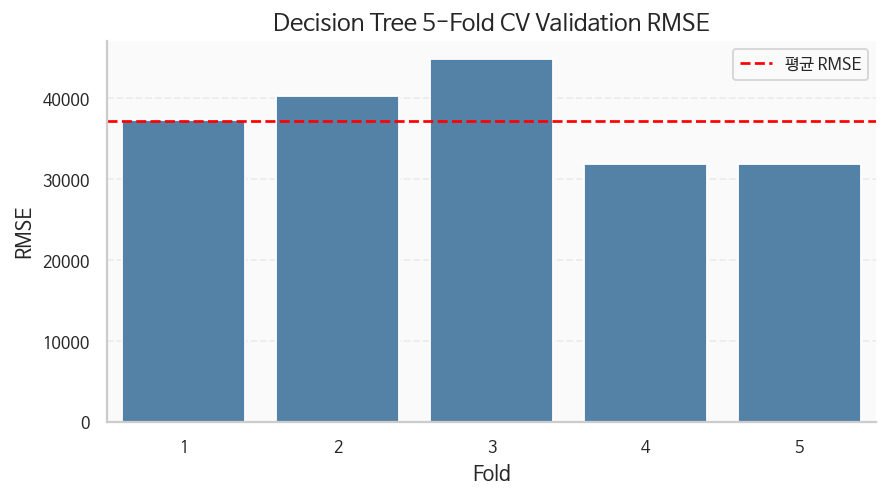

In [64]:
# fold별 RMSE 시각화
# 5번의 교차 검증(Fold) 각각에서 나온 검증 성능(RMSE)을 막대그래프로 비교합니다.


# 1. 도화지(Figure)와 축(Axes) 준비
# 가로 7, 세로 4 비율의 크기로 그래프를 그릴 준비를 합니다.
fig, ax = plt.subplots(figsize=(7, 4))

# 2. 막대그래프(Barplot) 그리기
# Seaborn 라이브러리를 사용해 교차 검증 결과(cv_summary) 데이터를 시각화합니다.
sns.barplot(
    data=cv_summary,        # 시각화할 데이터프레임
    x='fold',               # x축: 폴드 번호 (1~5)
    y='valid_rmse',         # y축: 해당 폴드의 평가용(모의고사) RMSE 오차 점수
    color='steelblue',      # 막대 색상을 'steelblue'(차분한 파란색)로 통일
    ax=ax,                  # 만들어둔 축(ax) 위에 그래프를 그림
)

# 3. 평균선(수평선) 추가하기
# 5번의 검증 RMSE 점수들의 전체 평균을 계산하여 빨간 점선으로 표시합니다.
ax.axhline(
    cv_summary.loc[:, 'valid_rmse'].mean(), # 5개 폴드의 RMSE 평균값 계산
    color='red',                            # 선 색상을 빨간색으로 지정
    linestyle='--',                         # 선 모양을 점선(dash)으로 설정
    label='평균 RMSE',                      # 범례(Legend)에 표시할 이름 지정
)

# 4. 그래프 디자인 꾸미기 (제목 및 축 라벨 설정)
ax.set_title('Decision Tree 5-Fold CV Validation RMSE')  # 그래프의 전체 제목 설정
ax.set_xlabel('Fold')                                    # x축 이름 설정
ax.set_ylabel('RMSE')                                    # y축 이름 설정 (오차 크기)

# 5. 범례 표시
# 위에서 수평선에 설정한 label('평균 RMSE')이 그래프 화면에 나타나도록 합니다.
ax.legend()

# 6. 최종 출력
# 그래프의 여백을 자동으로 깔끔하게 조정하여 글자나 축이 잘리지 않게 만들어 줍니다.
plt.tight_layout()
# 완성된 그래프를 화면에 출력합니다.
plt.show()

## 9. 최종 학습 및 테스트 데이터 평가

In [65]:
# 최종 학습
# 교차검증으로 학습 데이터 내부의 성능 변동을 확인한 뒤,
# 전체 X_train_ready로 최종 모델을 학습합니다.

pipeline.fit(X_train_ready, y_train)

y_pred = pipeline.predict(X_test_ready)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('--- 테스트 데이터 평가 결과 ---')
print(f'RMSE : {rmse:,.0f}')
print(f'MAE  : {mae:,.0f}')
print(f'R2   : {r2:.4f}')


--- 테스트 데이터 평가 결과 ---
RMSE : 41,545
MAE  : 26,196
R2   : 0.7750


In [66]:
# 실제값 vs 예측값 일부 확인
result_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
})
result_df.loc[:, 'error'] = result_df.loc[:, 'actual'] - result_df.loc[:, 'predicted']
result_df.head(10).round(0)


,actual,predicted,error
0,154500,135059.0,19441.0
1,325000,322340.0,2660.0
2,115000,115527.0,-527.0
3,159000,166746.0,-7746.0
4,315500,284006.0,31494.0
5,75500,104646.0,-29146.0
6,311500,166746.0,144754.0
7,146000,145962.0,38.0
8,84500,104646.0,-20146.0
9,135500,135059.0,441.0


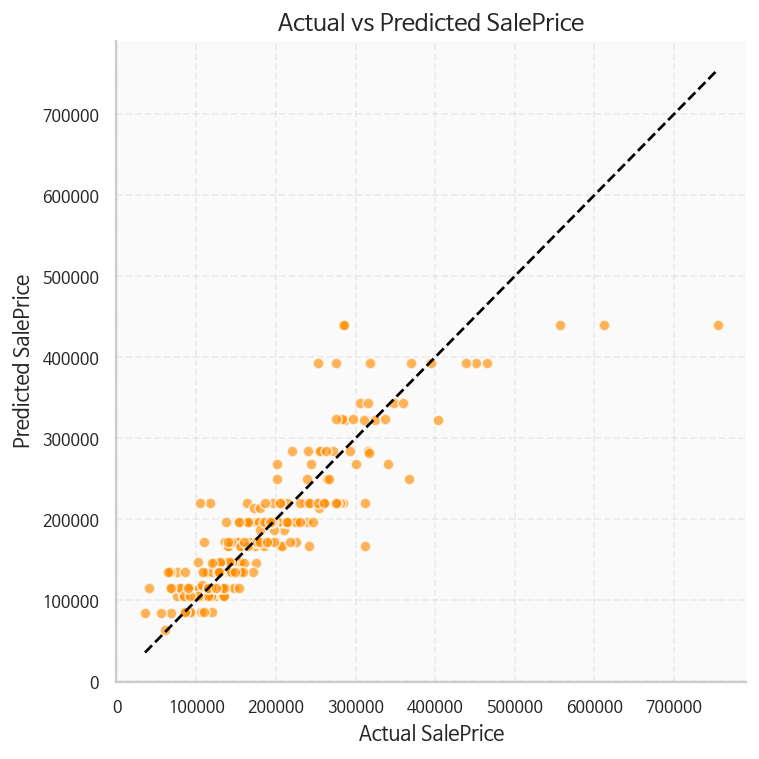

In [67]:
# 실제값과 예측값 산점도
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_pred, alpha=0.65, color='darkorange', edgecolors='white')

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
ax.plot([min_price, max_price], [min_price, max_price], color='black', linestyle='--')

ax.set_title('Actual vs Predicted SalePrice')
ax.set_xlabel('Actual SalePrice')
ax.set_ylabel('Predicted SalePrice')

plt.tight_layout()
plt.show()


## 10. Decision Tree 특성 중요도 확인

In [68]:
# 특성 중요도
# OneHotEncoder 이후 컬럼명이 늘어나므로, 전처리기에서 최종 컬럼명을 가져옵니다.

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
})
importance_df = importance_df.sort_values('importance', ascending=False)

importance_df.head(15)


,feature,importance
43,cat__QualBand_매우좋음,0.556886
1,num__TotalSF,0.350823
44,cat__QualBand_보통이하,0.035400
2,num__TotalBath,0.032754
0,num__HouseAge,0.021785
42,cat__CentralAir_Y,0.001831
3,num__HasGarage,0.000521
5,cat__Neighborhood_Blueste,0.000000
4,cat__Neighborhood_Blmngtn,0.000000
9,cat__Neighborhood_CollgCr,0.000000


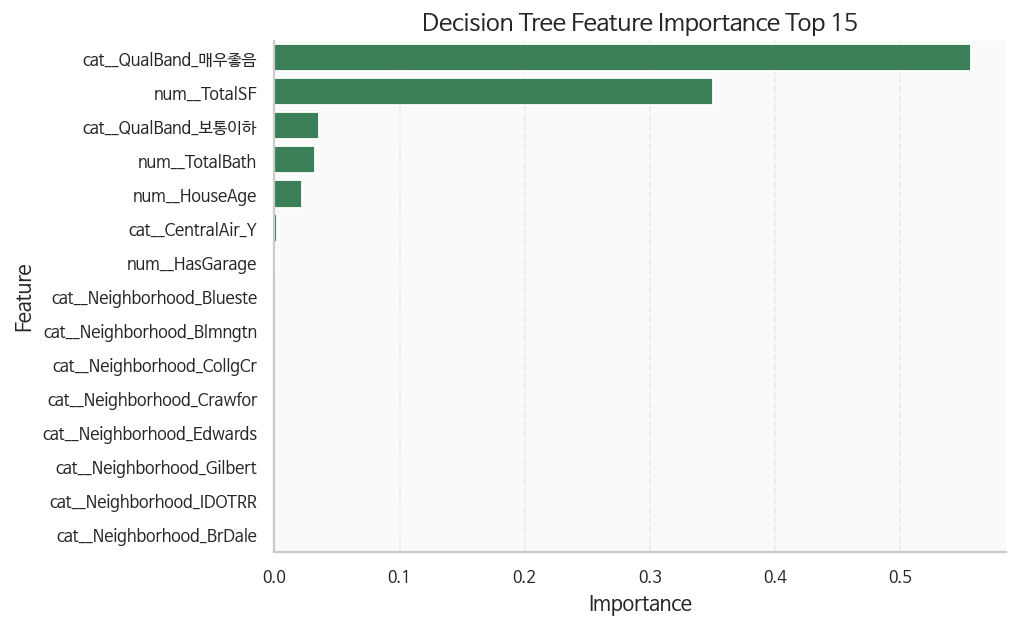

In [69]:
# 특성 중요도 시각화
top_importance = importance_df.head(15).copy()

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top_importance,
    x='importance',
    y='feature',
    color='seagreen',
    ax=ax,
)
ax.set_title('Decision Tree Feature Importance Top 15')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()


## 11. 새로운 집 1건 예측하기

마지막으로 수업용 샘플 입력을 하나 만들어 예측합니다.

중요한 점은 새 데이터도 반드시 **`prepare_house_features()`** 를 통과해야 한다는 것입니다.


In [70]:
# 새로운 집 1건 예측
new_house = pd.DataFrame([{
    'OverallQual': 7,
    'GrLivArea': 1700,
    'TotalBsmtSF': 900,
    'FullBath': 2,
    'HalfBath': 1,
    'BsmtFullBath': 1,
    'BsmtHalfBath': 0,
    'GarageCars': 2,
    'YearBuilt': 2005,
    'YrSold': 2010,
    'Neighborhood': 'CollgCr',
    'HouseStyle': '2Story',
    'ExterQual': 'Gd',
    'CentralAir': 'Y',
}])

new_house_ready = prepare_house_features(new_house)

predicted_price = pipeline.predict(new_house_ready)[0]

print(f'예상 판매 가격: ${predicted_price:,.0f}')
new_house_ready


예상 판매 가격: $195,953


,HouseAge,TotalSF,TotalBath,HasGarage,Neighborhood,HouseStyle,ExterQual,CentralAir,QualBand,AgeBand
0,5,2600,3.5,1.0,CollgCr,2Story,Gd,Y,좋음,신축


## 12. 옵션: Kaggle `test.csv` 예측 후 `submission.csv` 저장하기

실제 Kaggle 제출 흐름도 짧게 경험해봅니다.

- `test.csv`에는 `SalePrice`가 없습니다.
- `sample_submission.csv`의 형식을 그대로 사용합니다.
- 앞에서 만든 `prepare_house_features()` 함수로 `test.csv`에도 같은 전처리를 적용합니다.
- 학습된 `pipeline`으로 예측한 뒤 `submission.csv`로 저장합니다.


In [71]:
# Kaggle test.csv 예측 및 submission.csv 저장 (옵션)

kaggle_test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print('kaggle_test shape:', kaggle_test.shape)
print('sample_submission shape:', sample_submission.shape)
sample_submission.head()


kaggle_test shape: (1459, 80)
sample_submission shape: (1459, 2)


,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [62]:
# test.csv에서도 학습 때 선택했던 독립변수만 사용합니다.
kaggle_test_X = kaggle_test.loc[:, base_features].copy()

# 파생변수와 바이닝만 함수로 적용합니다.
# 결측치 처리와 표준화는 학습된 pipeline 내부에서 수행됩니다.
kaggle_test_ready = prepare_house_features(kaggle_test_X)

kaggle_pred = pipeline.predict(kaggle_test_ready)

submission = sample_submission.copy()
submission.loc[:, 'SalePrice'] = kaggle_pred

submission_path = '260704_submission.csv'
submission.to_csv(submission_path, index=False)

print(f'submission.csv 저장 완료: {submission_path}')
submission.head()


submission.csv 저장 완료: 260704_submission.csv


,Id,SalePrice
0,1461,115527.009091
1,1462,166746.373626
2,1463,172201.785714
3,1464,195953.389262
4,1465,213486.909091


## 정리

이번 Lv3 회귀 예제에서 배운 흐름은 다음과 같습니다.

1. 사용할 독립변수를 일부만 선택했습니다.
2. `train_test_split` 이후 파생변수와 바이닝을 진행했습니다.
3. 먼저 `X_train`에서 함수 없이 파생변수와 바이닝을 직접 수행했습니다.
4. 반복되는 로직을 `prepare_house_features()` 함수로 묶었습니다.
5. 결측치 처리, 표준화, 원핫인코딩은 `Pipeline` 내부에서 수행했습니다.
6. 모델은 **Decision Tree Regressor 하나만** 사용하고, **5-Fold 교차검증**으로 성능을 확인했습니다.
7. 옵션으로 Kaggle `test.csv`를 예측하고 `submission.csv` 파일을 저장했습니다.

